In [10]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [11]:
load_dotenv()

True

In [12]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

In [24]:
class UPSCEvalState(TypedDict):
    essay: str
    cot:str
    depthot:str
    language:str
    final:str

In [35]:
def cot(State:UPSCEvalState) -> UPSCEvalState:
    essay=State['essay']
    prompt=f"based upon essay :{essay} \n give the score between 1-10 based upon clarity of thought"
    ans=llm.invoke(prompt)
    
    return{
        "cot": ans.content
    }
    


In [36]:
def dot(State:UPSCEvalState) -> UPSCEvalState:
    essay=State['essay']
    prompt=f"based upon essay :{essay} \n give the score between 1-10 based upon depth of thought"
    ans=llm.invoke(prompt)
    
    return {
        "depthot": ans.content
    }


In [ ]:
def langScore(State:UPSCEvalState) -> UPSCEvalState:
    essay=State['essay']
    prompt=f"based upon essay :{essay} \n give the score between 1-10 based upon language used"
    ans=llm.invoke(prompt)
    return{
        "language": ans.content
    }

In [38]:
def finaleval(State:UPSCEvalState) -> UPSCEvalState:
    cot=State['cot']
    dot=State['depthot']
    lang=State['language']
    prompt=f"given score based upon clarity of thought :{cot} depth of thought : {dot} language used :{lang} give me final evaluation"
    ans =llm.invoke(prompt)
    return{
        "final": ans.content
    }

In [39]:
graph=StateGraph(UPSCEvalState)
graph.add_node("cot", cot)
graph.add_node("dot", dot)
graph.add_node("langscore",langScore)
graph.add_node("finaleval",finaleval)


In [42]:
graph.add_edge(START,"cot")
graph.add_edge(START,"dot")
graph.add_edge(START,"langscore")
graph.add_edge("cot","finaleval")
graph.add_edge("dot","finaleval")
graph.add_edge("langscore","finaleval")
graph.add_edge("finaleval",END)
workflow= graph.compile()

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [41]:
essay = {
    "essay": (
        "Hockey is a popular outdoor game played between two teams of eleven players each. "
        "The players use curved sticks to hit a ball into the opponent's goal. "
        "The team that scores the most goals wins the match. "
        "Hockey is a fast and exciting game that requires speed, teamwork, and skill. "
        "It is the national sport of India and is enjoyed by people all over the world. "
        "Playing hockey helps improve physical fitness, discipline, and sportsmanship."
    )
}

result = workflow.invoke(essay)

In [45]:
result["final"]

"Based on the evaluation, here is a final assessment of the essay:\n\n**Clarity of Thought: 8/10**\nThe essay is clear and easy to understand, with a good introduction, simple language, and coverage of key points. However, it lacks depth and supporting examples, and the conclusion is somewhat generic.\n\n**Depth of Thought: 4/10**\nThe essay provides a basic overview of the game of hockey but lacks analysis, critical thinking, and nuance. It doesn't explore the game's strategies, tactics, or cultural significance, and doesn't raise thought-provoking questions.\n\n**Language Used: 6/10**\nThe language is simple and easy to understand, but lacks variety, complexity, and creativity. The essay could benefit from more descriptive phrases, adjectives, and varied sentence structures to make it more engaging and effective.\n\n**Overall Evaluation: 18/30**\nThe essay is clear and easy to understand, but lacks depth, analysis, and sophistication. To improve, the essay could explore more nuanced 

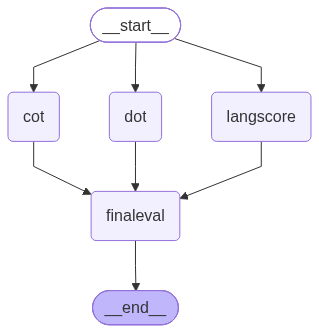

In [46]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())